# 06 · Прикладные данные и маятники

Реальные и модельные записи: закон известен только для одиночного маятника. Для остальных найденное уравнение -- результат, который нужно интерпретировать. В конце — прикладная проверка идеализированной модели ball-and-beam.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
%matplotlib inline
print('EPDE imported; PIC notebook environment ready')

EPDE imported; PIC notebook environment ready


## `pend_single` · Реальный одиночный маятник (энкодер, стенд HardwareX)

pend_single: Real single pendulum (encoder, HardwareX rig)
  class: ODE (one equation), source: real
  axes: t; data shape: (5000,); variables: theta
  t: [0, 20], 5000 points
  truth:
    -64.8 * theta{power: 1.0} + -0.65 * dtheta/dx0{power: 1.0} = d^2theta/dx0^2{power: 1.0}
  + 1 equivalent form(s)
  notes: Small swing about the hanging position, angle centred (theta - pi): a damped linear oscillator, -64.8 = -g/l. The undamped form also counts (damping is weak).


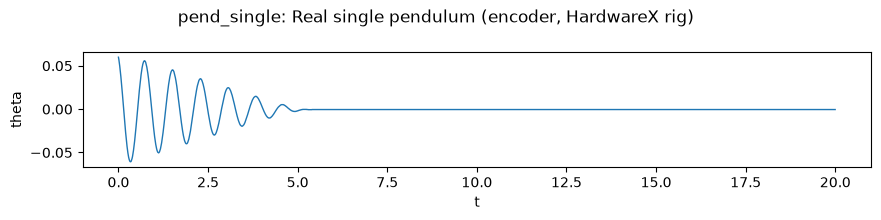

In [2]:
p = datasets.load('pend_single')
print(p.summary())
plot_problem(p); plt.show()

In [3]:
p, report = check('pend_single', noise_levels=[0, 1, 5])
print_check(p, report)

pend_single: Real single pendulum (encoder, HardwareX rig)
  class: ODE (one equation), source: real
  axes: t; data shape: (5000,); variables: theta
  t: [0, 20], 5000 points
  truth:
    -64.8 * theta{power: 1.0} + -0.65 * dtheta/dx0{power: 1.0} = d^2theta/dx0^2{power: 1.0}
  + 1 equivalent form(s)
  notes: Small swing about the hanging position, angle centred (theta - pi): a damped linear oscillator, -64.8 = -g/l. The undamped form also counts (damping is weak).

=== noise 0 % ===
R^2 of the true structure: 0.997326   (d^2theta/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  theta{'power': 1.0}                                             -64.8      -65.059            9.956e-01
  dtheta/dx0{'power': 1.0}                                        -0.65      -0.6456            5.883e-03

=== noise 1 % ===
R^2 of the true structure: 0.994949   (d^2theta/dx0^2{power: 1.0})
  term                                  

In [4]:
from epde_bench.nbcache import cached_run
rec = cached_run('pend_single', variant='default', noise=0.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok fit 203 s (from cache)
[0]
     -0.3971403679659164 * x{power: 1.0, dim: 0.0} * dtheta/dx0{power: 1.0} + -65.00677833295948 * theta{power: 1.0} + 0.0 = d^2theta/dx0^2{power: 1.0}
[1]
     -64.78250995803194 * theta{power: 1.0} + 0.0 = d^2theta/dx0^2{power: 1.0}
[2]
     -64.78250995803194 * theta{power: 1.0} + 0.0 = d^2theta/dx0^2{power: 1.0}
[3]
     -65.06895142145255 * theta{power: 1.0} + -0.3973565420470713 * dtheta/dx0{power: 1.0} * x{power: 1.0, dim: 0.0} + -0.002212360068902907 * x{power: 1.0, dim: 0.0} + 0.0 = d^2theta/dx0^2{power: 1.0}
[4] <- compromise pick
     -0.0811084908569737 * x{power: 2.0, dim: 0.0} * dtheta/dx0{power: 1.0} + -0.4063119822527091 * dtheta/dx0{power: 1.0} + -65.00975483785909 * theta{power: 1.0} + 0.0 = d^2theta/dx0^2{power: 1.0}
[5]
     -64.78250995803194 * theta{power: 1.0} + 0.0 = d^2theta/dx0^2{power: 1.0}
[6]
     -65.00677833295939 * theta{power: 1.0} + -0.39714036796591606 * dtheta/dx0{power: 1.0} * x{power: 1.0, dim: 0.0} + 0.0 = d^2theta/dx

## `dp_sim` · Двойной маятник, моделирование

dp_sim: Simulated double pendulum
  class: system of ODEs, source: synthetic
  axes: t; data shape: (1001,); variables: theta1, theta2
  t: [0, 10], 1001 points
  truth: unknown
  notes: Used by the PINN studies in dp/. The equations of motion need coupling tokens and are not written in token form here.


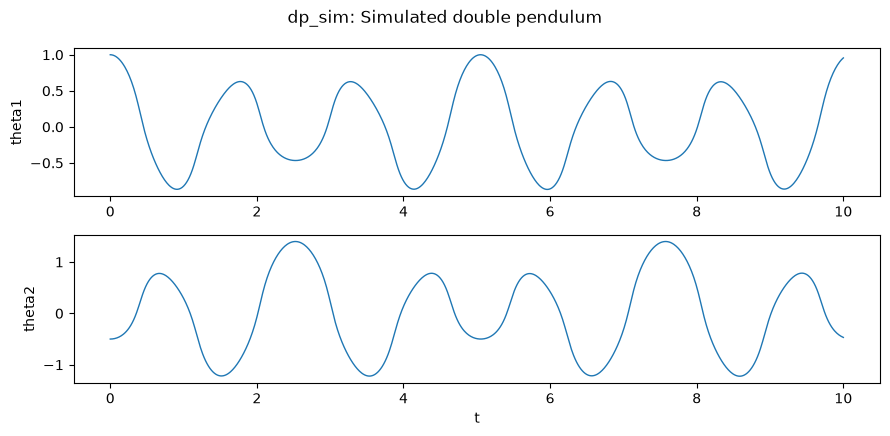

In [5]:
p = datasets.load('dp_sim')
print(p.summary())
plot_problem(p); plt.show()

Запуск на `dp_sim` идёт долго (его время -- в ноутбуке бенчмарка `07`), поэтому
здесь не выполняется. Запуск: `python projects/pic/bench.py run dp_sim`.

## `dp_video` · Реальный двойной маятник (видеотрекинг)

dp_video: Real double pendulum (video tracking)
  class: system of ODEs, source: real
  axes: t; data shape: (38827,); variables: theta1, theta2
  t: [0, 77.65], 38827 points
  truth: unknown
  notes: Mean link angles from video markers (row 0 = time, row 1 = angle). Noisier than the encoder record; dp_encoder is the preferred source.


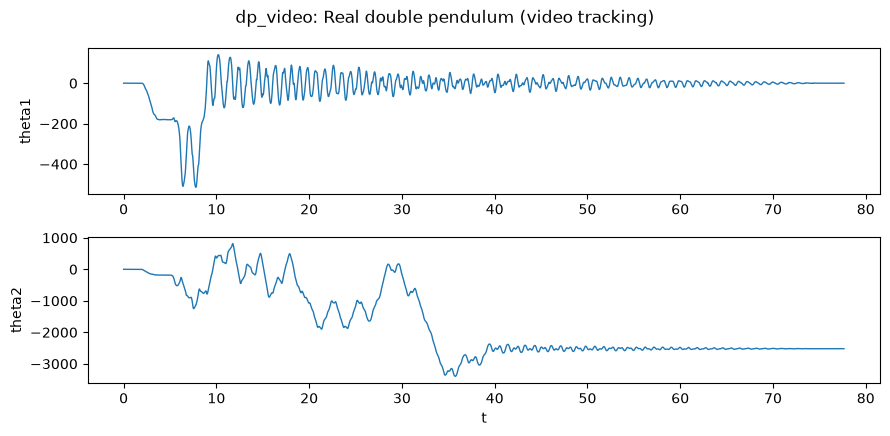

In [6]:
p = datasets.load('dp_video')
print(p.summary())
plot_problem(p); plt.show()

Запуск на `dp_video` идёт долго (его время -- в ноутбуке бенчмарка `07`), поэтому
здесь не выполняется. Запуск: `python projects/pic/bench.py run dp_video`.

## `dp_encoder` · Реальный двойной маятник (энкодер, стенд HardwareX)

dp_encoder: Real double pendulum (encoder, HardwareX rig)
  class: system of ODEs, source: real
  axes: t; data shape: (6000,); variables: theta1, theta2
  t: [0, 24], 6000 points
  truth: unknown
  notes: Coupled Lagrangian equations with cos/sin of the angle difference; their exact coefficients are not known, so the run is not scored. sin(theta) and the coupling factors enter as tokens.

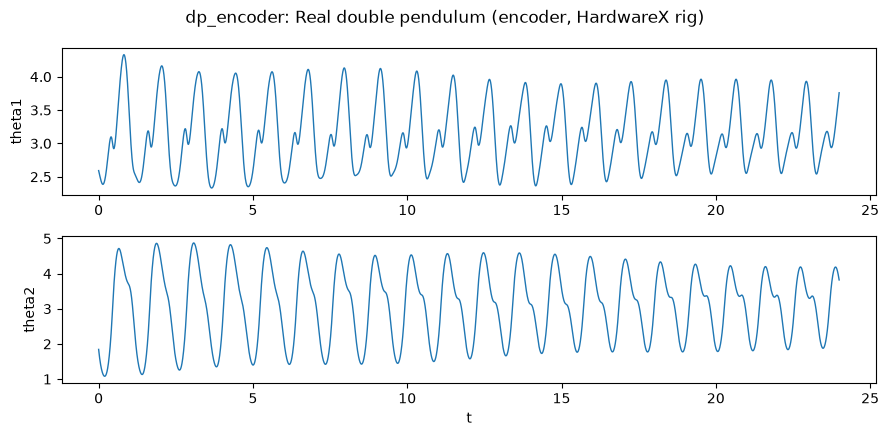

In [7]:
p = datasets.load('dp_encoder')
print(p.summary())
plot_problem(p); plt.show()

Запуск на `dp_encoder` идёт долго (его время -- в ноутбуке бенчмарка `07`), поэтому
здесь не выполняется. Запуск: `python projects/pic/bench.py run dp_encoder`.

## `robot_arm` · DaISy: гибкая рука робота (момент -> ускорение)

robot_arm: DaISy flexible robot arm (input torque -> acceleration)
  class: ODE (one equation), source: real
  axes: t; data shape: (1024,); variables: y
  t: [0, 10.23], 1024 points
  truth: unknown
  notes: Unknown truth (a ~5th-order flexible structure). dt is not distributed with the file; 0.01 s is assumed (coefficients scale with it, structure does not).


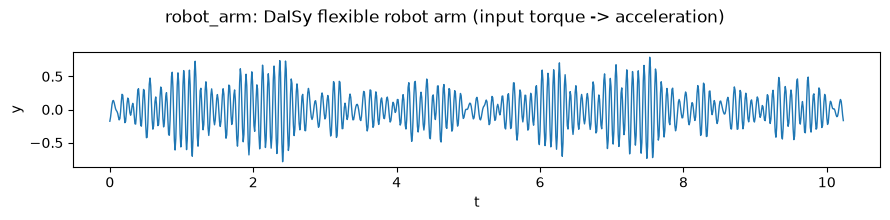

In [8]:
p = datasets.load('robot_arm')
print(p.summary())
plot_problem(p); plt.show()

In [9]:
from epde_bench.nbcache import cached_run
rec = cached_run('robot_arm', variant='default', noise=0.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok fit 158 s (from cache)
[0]
     -5263.949000589646 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[1]
     -5263.949000589646 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[2] <- compromise pick
     -5263.949000589648 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[3]
     -5263.949000589646 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[4]
     -5263.949000589646 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[5]
     -5263.949000589646 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[6]
     -5263.949000589646 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[7]
     -5263.949000589648 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[8]
     -5263.949000589646 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[9]
     -5263.949000589648 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[10]
     -5263.949000589646 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[11]
     -5263.949000589646 * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[12]
     -5263.949000589648 * y{power: 1.0} + 0.0 = 

## `ballbeam` · DaISy: шар на балке (угол балки -> положение шара)

ballbeam: DaISy ball and beam (beam angle -> ball position)
  class: ODE (one equation), source: real
  axes: t; data shape: (1000,); variables: y
  t: [0, 99.9], 1000 points
  truth: unknown
  notes: Unknown truth; idealised physics is y'' proportional to the beam angle. Sampling period 0.1 s per the DaISy description.


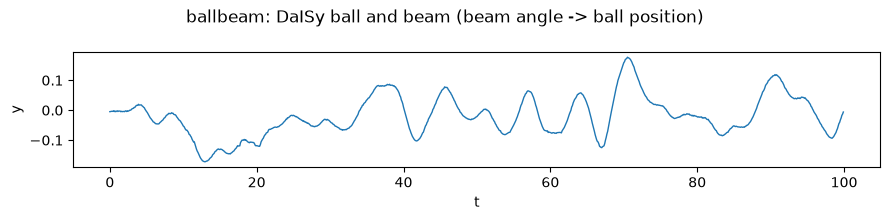

In [10]:
p = datasets.load('ballbeam')
print(p.summary())
plot_problem(p); plt.show()

In [11]:
from epde_bench.nbcache import cached_run
rec = cached_run('ballbeam', variant='default', noise=0.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok fit 177 s (from cache)
[0] <- compromise pick
     4.381471884406824 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[1]
     4.381471884406824 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[2]
     4.381471884406822 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[3]
     4.381471884406824 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[4]
     4.381471884406819 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[5]
     4.381471884406822 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[6]
     4.381471884406819 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[7]
     4.381471884406824 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[8]
     4.381471884406824 * u_in{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0}
[9]
     -2.7739858269972033 * u_in{power: 1.0} * d^2y/dx0^2{power: 1.0} + 2.4649995198095325 * u_in{power: 1.0} * y{power: 1.0} + 0.0 = d^2y/dx0^2{power: 1.0} * y{power: 1.0}
{'front_size': 10, 'selected_index': 0}


## `sst` · Температура поверхности моря, ESA CCI L4 (янв-мар 2025)

sst: Sea surface temperature, ESA CCI L4 (Jan-Mar 2025)
  class: PDE, 2 space dimensions, source: real
  axes: t, lat, lon; data shape: (90, 268, 384); variables: T
  t: [0, 89], 90 points
  lat: [25.02, 38.38], 268 points
  lon: [-44.97, -25.83], 384 points
  truth: unknown
  notes: Daily analysed SST (K), 90 days. By default the largest rectangular ocean region finite at every frame is used; crop_ocean=False loads the original NaN-masked box for plotting only. sst/sst_l4.nc is a ZIP archive of the same daily files despite its extension.


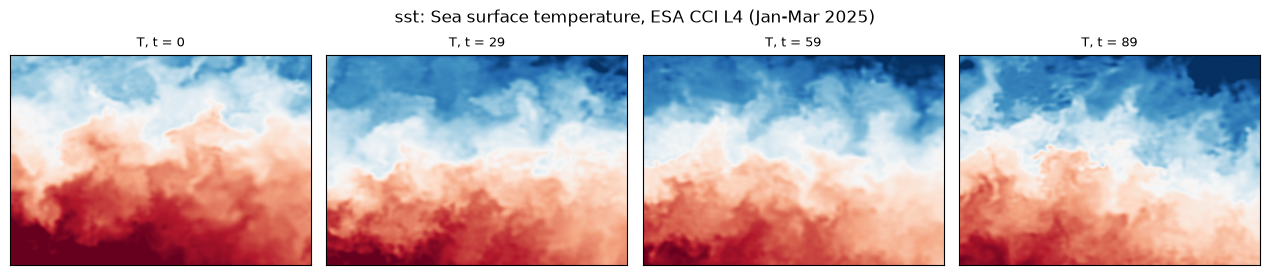

In [12]:
p = datasets.load('sst')
print(p.summary())
plot_problem(p); plt.show()

По умолчанию `crop_ocean=True`: загрузчик выбирает максимальный прямоугольник океана, конечный во все дни. Исходная область с сушей (`crop_ocean=False`) содержит NaN и предназначена только для просмотра; такой массив нельзя передавать поиску.

Запуск на `sst` идёт долго (его время -- в ноутбуке бенчмарка `07`), поэтому
здесь не выполняется. Запуск: `python projects/pic/bench.py run sst`.

## Ball-and-beam: применимость $y'' = a u_{in}$

Пользовательская задача: оценить, достаточно ли простой связи угла балки с
ускорением шарика для расчёта вынужденного движения. Из фронта выше можно проверить,
встречается ли структура `d^2y/dx0^2 ~ u_in`; выбранное уравнение печатается отдельно.
Поиск выше использует весь файл и потому является исследовательским: его коэффициент
не служит независимой оценкой на отложенной части.

Следующая проверка **заранее фиксирует физическую гипотезу** $y''=a u_{in}$.
Первые 70% последовательности — обучение, последние 30% — проверка. Коэффициент
подгоняется только на обучении, производные EPDE FD вычисляются отдельно в каждой
части, по 8 краевых точек исключаются. Поэтому тестовые значения не попадают
в обучение через дифференцирование. Это проверка гипотезы, а не независимая оценка
точности выбора структуры EPDE на полном файле.

Положение интегрируется с измеренным тестовым входом и начальным положением/скоростью
из тестового старта. Это условный отклик на известный вход. R² ускорения проверяет
локальную связь; дрейф интегральной траектории выявляет смещение, пропущенную динамику
и ошибки начальной скорости. Отрицательный R² означает ошибку больше постоянного
среднего, а не успех. Масштаб коэффициента зависит от единиц входа и dt=0.1 с;
истинное уравнение для этих измерений не заявляется.

{'coefficient': 4.421889443526599, 'train_stop': 69.9, 'test_start': 70.0, 'train_samples': 684, 'test_samples': 284, 'acceleration': {'rmse': 0.060592241378360674, 'r2': 0.21466731312497234}, 'trajectory': {'rmse': 0.8149714275901534, 'r2': -169.5498799864858}}


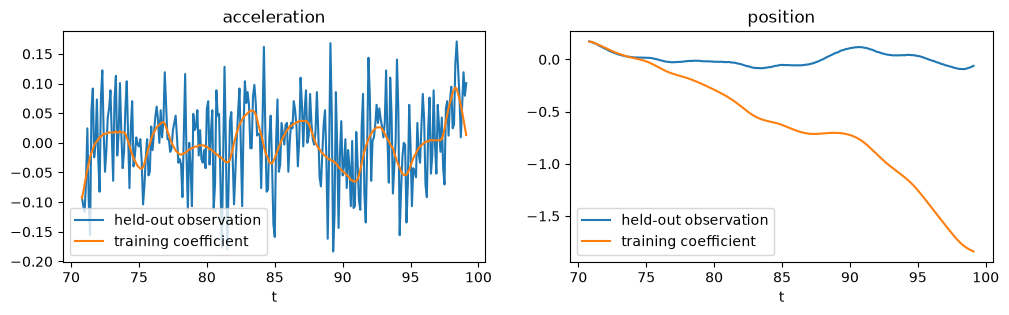

In [13]:
from epde_bench.application import ballbeam_validation
validation = ballbeam_validation()
print({k: validation[k] for k in ['coefficient', 'train_stop', 'test_start',
      'train_samples', 'test_samples', 'acceleration', 'trajectory']})
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, actual, predicted, label in [
    (axes[0], 'observed_acceleration', 'predicted_acceleration', 'acceleration'),
    (axes[1], 'observed_y', 'predicted_y', 'position')]:
    ax.plot(validation['time'], validation[actual], label='held-out observation')
    ax.plot(validation['time'], validation[predicted], label='training coefficient')
    ax.set_title(label); ax.set_xlabel('t'); ax.legend()
plt.show()